<a href="https://colab.research.google.com/github/AJasa1983/Assessment_Repo/blob/main/programmng_for_Data_Analysis_st20350980.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setting up the Environment
#importing Libraries and Connect to Github

In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

# Set a consistent visual style for all matplotlib/seaborn charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# ── GITHUB SETUP ─────────────────────────────────────────────────────────
# Configure Git identity — this is required so Git knows who is making commits
! git config --global user.name "AJasa1983"
! git config --global user.email "ofemomini60@gmail.com"

# Store your GitHub credentials
username = "AJasa1983"
repo     = "Assessment_Repo"

# Clone the repository if it hasn't been cloned yet in this session
# The '-f' flag in 'test -d' checks whether the folder already exists
import os
if not os.path.exists(repo):
    os.system(f'git clone https://github.com/{username}/{repo}')
    print(f'Cloned {repo} successfully.')
else:
    print(f'{repo} already exists — skipping clone.')

# Move into the repository folder so all file operations happen there
%cd {repo}
print('Working directory:', os.getcwd())

Cloned Assessment_Repo successfully.
/content/Assessment_Repo
Working directory: /content/Assessment_Repo


Merging the csv files

In [3]:
# LOAD & MERGE DATA
# ──────────────────────────────────────
# glob.glob finds all CSV files in the current directory
city_files = glob.glob('*.csv')
print(f'CSV files found: {city_files}')

# Read each file into a list, then concatenate into one DataFrame
all_data = []
for f in city_files:
    temp = pd.read_csv(f)
    all_data.append(temp)
    print(f'  Loaded {f} — {len(temp):,} rows')

# pd.concat stacks all DataFrames on top of each other (row-wise)
# ignore_index=True resets the index to be continuous 0, 1, 2 ...
df = pd.concat(all_data, ignore_index=True)

print(f'\nMerged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

CSV files found: ['PRSA_Data_Tiantan_20130301-20170228.csv', 'PRSA_Data_Huairou_20130301-20170228.csv', 'PRSA_Data_Dongsi_20130301-20170228.csv', 'PRSA_Data_Shunyi_20130301-20170228.csv']
  Loaded PRSA_Data_Tiantan_20130301-20170228.csv — 35,064 rows
  Loaded PRSA_Data_Huairou_20130301-20170228.csv — 35,064 rows
  Loaded PRSA_Data_Dongsi_20130301-20170228.csv — 35,064 rows
  Loaded PRSA_Data_Shunyi_20130301-20170228.csv — 35,064 rows

Merged dataset: 140,256 rows x 18 columns


DATA UNERSTANDING

Before any Analysis, we need to understand what the Datasets looks like.
1. How many Eows and columns does it have?
2. What are the Data types of each column?
3. Are there any missing values we need to handle?
4. Statistical details about the ranges and distribution

In [4]:
# ── SHAPE & COLUMNS ────────────────────────────────────────────────

print('=' * 55)
print(f'  Total Rows    : {df.shape[0]:,}')
print(f'  Total Columns : {df.shape[1]}')
print('=' * 55)

# List of all column names so we know what variables are available
print('\nColumn Names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

  Total Rows    : 140,256
  Total Columns : 18

Column Names:
   1. No
   2. year
   3. month
   4. day
   5. hour
   6. PM2.5
   7. PM10
   8. SO2
   9. NO2
  10. CO
  11. O3
  12. TEMP
  13. PRES
  14. DEWP
  15. RAIN
  16. wd
  17. WSPM
  18. station


In [5]:
# DATA TYPES ─────────────────────────────────────────────────────
# this explains how pandas has interpreted each column.
# the 'int64' and 'float64' are numeric columns.
# object =(like station name or wind direction).

print('Column Data Types:')
print(df.dtypes)

print('\nFirst 15 rows of data:')
display(df.head(15))

Column Data Types:
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object

First 15 rows of data:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan
5,6,2013,3,1,5,10.0,10.0,12.0,15.0,400.0,70.0,-2.4,1027.5,-21.3,0.0,NW,2.4,Tiantan
6,7,2013,3,1,6,8.0,19.0,12.0,14.0,400.0,72.0,-2.5,1028.2,-20.4,0.0,NW,2.2,Tiantan
7,8,2013,3,1,7,7.0,7.0,12.0,19.0,400.0,67.0,-1.4,1029.5,-20.4,0.0,NNW,3.0,Tiantan
8,9,2013,3,1,8,3.0,6.0,14.0,29.0,500.0,56.0,-0.3,1030.4,-21.2,0.0,NW,4.6,Tiantan
9,10,2013,3,1,9,8.0,2.0,11.0,22.0,500.0,65.0,0.4,1030.5,-23.3,0.0,N,5.5,Tiantan


Columns with Missing Values:


,Missing Count,Missing %
CO,7923,5.65
NO2,5349,3.81
O3,4147,2.96
SO2,4057,2.89
PM2.5,3293,2.35
PM10,2475,1.76
wd,941,0.67
TEMP,142,0.10
PRES,144,0.10
DEWP,147,0.10


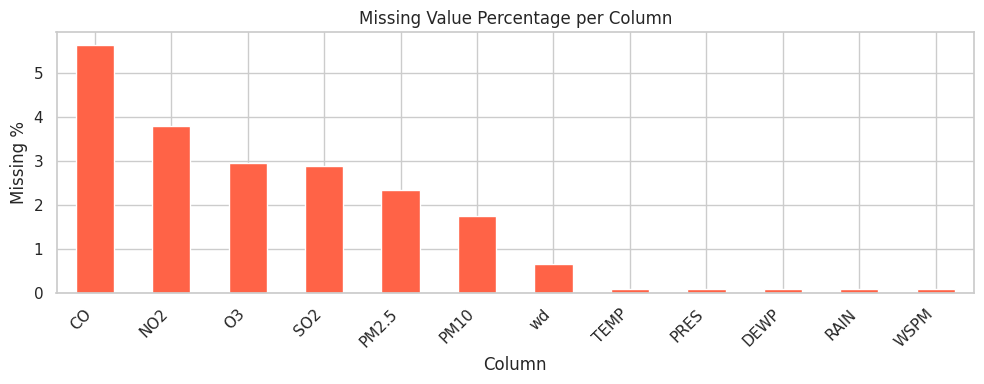

In [6]:
# ──MISSING VALUES ───────

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct
})

# Only show columns that actually have missing values
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with Missing Values:')
display(missing_report)

missing_report['Missing %'].plot(
    kind='bar', figsize=(10, 4), color='tomato', edgecolor='white'
)
plt.title('Missing Value Percentage per Column')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

OBSERVATIONS

* The combined Dataset has 140,256 hourly records across 4 stations between (2013 - 2017)
* Each station contributes 35,064 rows - the data is evenly distributed
* Pollutant columns (pm2.5, pm10, SO2, NO2, CO, 03) and metrological column (TEMP, PRES, DEWP, RAIN, WSPM) have varying amount of missing data.
* PM2.5 values have a high maximum, suggesting pluution spikes (outlier)
* Year ranges from 2013 - 2017; hour ranges from 0 to 23- hourly resolution
* The 'WD' column (Wind direction) is categoricaly (text), all others are numeric

In [7]:
# STATISTICAL SUMMARY ────────────────────────────────────────────
# shows count, mean, std deviation, min, max, and quartiles
# spotting outliers and understand ranges.

print('Statistical Summary of Numeric Columns:')
display(df.describe().round(2))

# How many records does each station have?
print('\nRecord Count per Station:')
print(df['station'].value_counts())

Statistical Summary of Numeric Columns:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.00,140256.00,140256.00,140256.00,140256.00,136963.00,137781.00,136199.00,134907.00,132333.00,136109.00,140114.00,140112.00,140109.00,140110.00,140135.00
mean,17532.50,2014.66,6.52,15.73,11.50,79.39,101.75,14.66,45.86,1208.21,57.06,13.29,1011.44,2.40,0.06,1.80
std,10122.14,1.18,3.45,8.80,6.92,80.42,90.54,20.58,32.15,1115.95,56.72,11.55,10.42,13.85,0.80,1.27
min,1.00,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.80,-43.40,0.00,0.00
25%,8766.75,2014.00,4.00,8.00,5.75,20.00,34.00,2.00,21.00,500.00,12.00,3.00,1003.00,-9.00,0.00,1.00
50%,17532.50,2015.00,7.00,16.00,11.50,55.00,80.00,6.00,39.00,900.00,45.00,14.30,1011.00,3.00,0.00,1.50
75%,26298.25,2016.00,10.00,23.00,17.25,111.00,141.00,18.00,64.00,1500.00,81.00,23.10,1019.70,15.10,0.00,2.30
max,35064.00,2017.00,12.00,31.00,23.00,941.00,999.00,315.00,258.00,10000.00,1071.00,41.10,1042.80,29.10,46.40,12.90



Record Count per Station:
station
Tiantan    35064
Huairou    35064
Dongsi     35064
Shunyi     35064
Name: count, dtype: int64


DATA PREPROCESSING

In this Section we will;
* Create a datetime column - combines year/month/day/hour into one proper     timestamp
* Remove duplicates - Avoid double-counting rows
* Handle missing values _ fills gaps using forwardf - fill (last known value) per station
* Feature engineering - Add useful new columns season, AQI category.

NOTE:
These steps ensures the data is clean, consistent and enriched for Analysis

In [8]:
# ── CREATE DATETIME COLUMN ─────────────────────────────────────────
# for time-based filtering, grouping, and plotting.

df['datetime'] = pd.to_datetime(
    df[['year', 'month', 'day', 'hour']]
)

# Set datetime as the index — useful for time-series operations
df = df.sort_values('datetime').reset_index(drop=True)

print('Datetime column sample:')
print(df[['year','month','day','hour','datetime']].head(3))
print(f'\nDate range: {df["datetime"].min()} → {df["datetime"].max()}')

Datetime column sample:
   year  month  day  hour   datetime
0  2013      3    1     0 2013-03-01
1  2013      3    1     0 2013-03-01
2  2013      3    1     0 2013-03-01

Date range: 2013-03-01 00:00:00 → 2017-02-28 23:00:00


In [9]:
# ── REMOVE DUPLICATES ───────────────────────────────────────────────
# Duplicate rows can skew statistics and model training, so We check and remove them here.

before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f'Rows before deduplication : {before:,}')
print(f'Rows after  deduplication : {after:,}')
print(f'Duplicates removed        : {before - after}')

Rows before deduplication : 140,256
Rows after  deduplication : 140,256
Duplicates removed        : 0


In [10]:
# HANDLE MISSING VALUES ─

numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

df[numeric_cols] = (
    df.groupby('station')[numeric_cols]
      .transform(lambda x: x.ffill().bfill())
)

# Confirm missing values are resolved
remaining = df[numeric_cols].isnull().sum()
print('Missing values remaining after fill:')
print(remaining[remaining > 0] if remaining.sum() > 0 else 'None — all filled!')

Missing values remaining after fill:
None — all filled!


In [11]:
# FEATURE ENGINEERING — SEASON ───────────────────────────────────
# Seasons are important for air quality analysis because:
#   - Winter: coal heating increases PM2.5
#   - Summer: heat drives O3 formation
# We map month numbers to season names using a dictionary.

season_map = {
    12: 'Winter', 1: 'Winter',  2: 'Winter',
     3: 'Spring', 4: 'Spring',  5: 'Spring',
     6: 'Summer', 7: 'Summer',  8: 'Summer',
     9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

print('Season distribution:')
print(df['season'].value_counts())

Season distribution:
season
Spring    35328
Summer    35328
Autumn    34944
Winter    34656
Name: count, dtype: int64


In [12]:
# FEATURE ENGINEERING — AQI CATEGORY ───────────────────────

def aqi_category(pm25):
    """Classify PM2.5 value into an AQI health category."""
    if pd.isna(pm25):        return 'Unknown'
    elif pm25 <= 12.0:       return 'Good'
    elif pm25 <= 35.4:       return 'Moderate'
    elif pm25 <= 55.4:       return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150.4:      return 'Unhealthy'
    elif pm25 <= 250.4:      return 'Very Unhealthy'
    else:                    return 'Hazardous'

df['AQI_Category'] = df['PM2.5'].apply(aqi_category)

print('AQI Category distribution:')
print(df['AQI_Category'].value_counts())

AQI Category distribution:
AQI_Category
Unhealthy                         48625
Moderate                          30663
Good                              21929
Unhealthy for Sensitive Groups    17836
Very Unhealthy                    15010
Hazardous                          6193
Name: count, dtype: int64


In [13]:
# FEATURE ENGINEERING — STATION TYPE ───────────────────────
# pollution comparism levels between urban and suburban zones.

inner_stations = ['Dongsi', 'Tiantan']
df['station_type'] = df['station'].apply(
    lambda x: 'Inner (Urban)' if x in inner_stations else 'Outer (Suburban)'
)

print('Station type counts:')
print(df['station_type'].value_counts())

print('\nFinal dataset shape after preprocessing:', df.shape)
print('\nNew columns added: datetime, season, AQI_Category, station_type')
display(df[['datetime','station','station_type','season','AQI_Category','PM2.5']].head(5))

Station type counts:
station_type
Inner (Urban)       70128
Outer (Suburban)    70128
Name: count, dtype: int64

Final dataset shape after preprocessing: (140256, 22)

New columns added: datetime, season, AQI_Category, station_type


,datetime,station,station_type,season,AQI_Category,PM2.5
0,2013-03-01 00:00:00,Tiantan,Inner (Urban),Spring,Good,6.0
1,2013-03-01 00:00:00,Huairou,Outer (Suburban),Spring,Good,7.0
2,2013-03-01 00:00:00,Dongsi,Inner (Urban),Spring,Good,9.0
3,2013-03-01 00:00:00,Shunyi,Outer (Suburban),Spring,Good,3.0
4,2013-03-01 01:00:00,Huairou,Outer (Suburban),Spring,Good,4.0


STATISTICAL ANALYSIS & VISUALISATION

Right now the Data is clean, let's noe explore it visually and statistically...

* Univariate: This examines each variable individual (distribution)
* Bivariate: explore relationships between pairs of variables (scatter plots, box plots)
* Multivariate: examines multi variables together (heatmaps, grouped bar charts, time series)

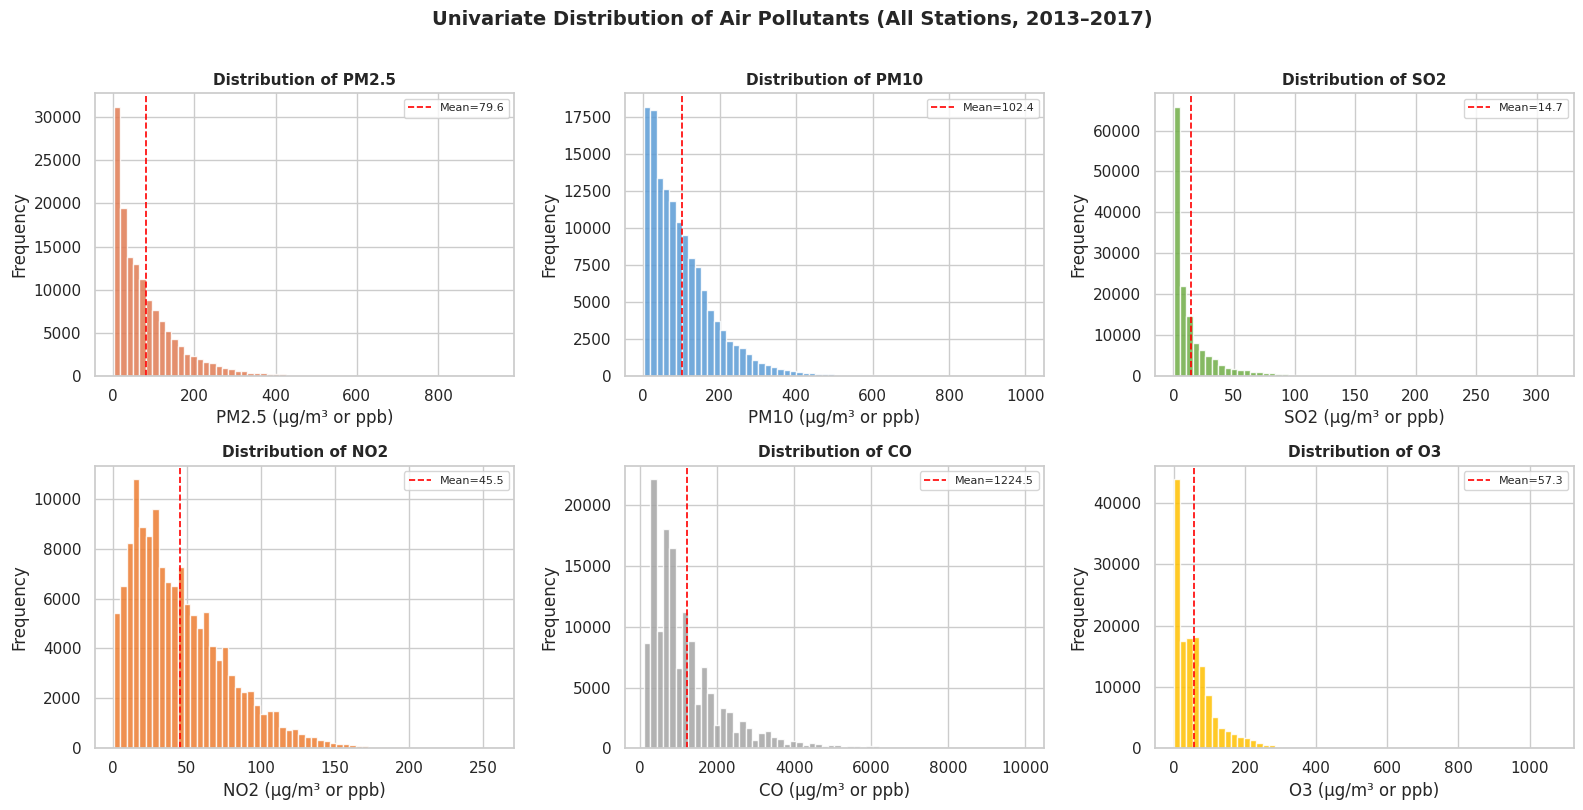

In [14]:
# UNIVARIATE — POLLUTANT DISTRIBUTIONS ───────────────────────────
# A histogram shows the frequency distribution of each pollutant.
# Skewed distributions (long right tails) indicate occasional high-pollution spikes.
# This is important for deciding how to handle outliers before model building.

pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

colors = ['#E07B54', '#5B9BD5', '#70AD47', '#ED7D31', '#A5A5A5', '#FFC000']

for i, col in enumerate(pollutants):
    axes[i].hist(df[col].dropna(), bins=60, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f'{col} (µg/m³ or ppb)')
    axes[i].set_ylabel('Frequency')
    # Add a vertical line at the mean
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean={mean_val:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate Distribution of Air Pollutants (All Stations, 2013–2017)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_01_pollutant_distributions.png', bbox_inches='tight')
plt.show()



THIS IS INTERPRETATION

All pollutant distributions are rigt - skewed (long tail on the right).
This means that most readings are low, but there are occasional extreme spikes.
CO has the widest spread, reflecting its link to traffic and combustion.
O3 shows a more symmetric distribution, infliuenced by photochemical reactions.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


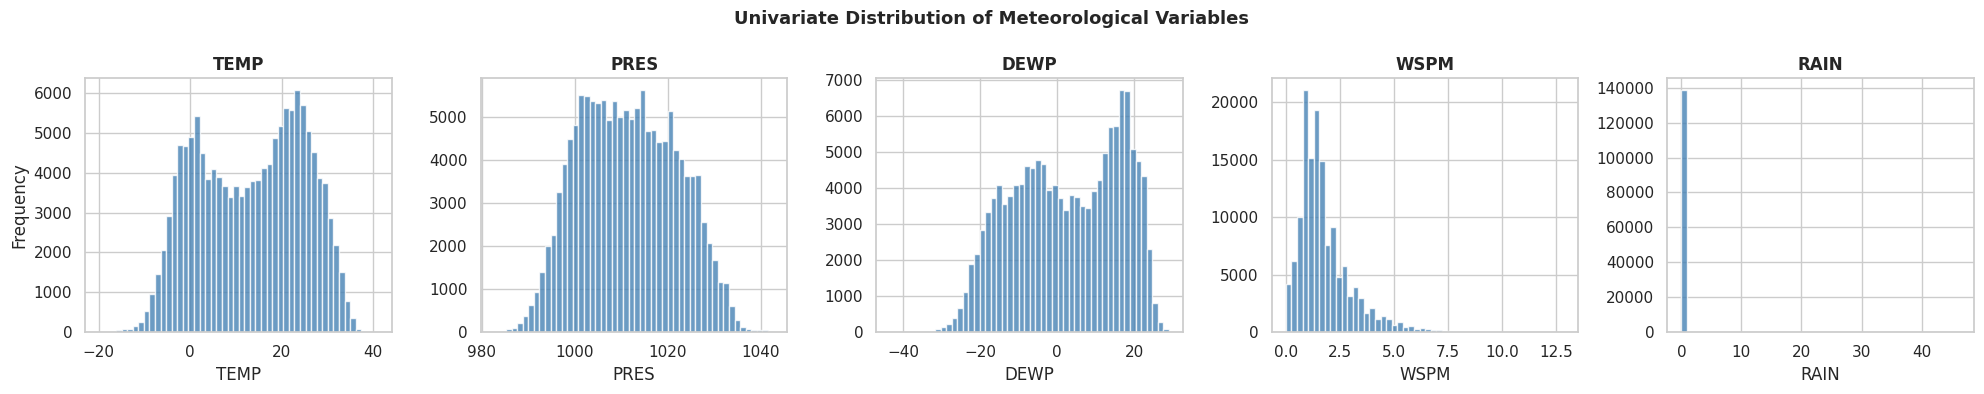

In [16]:
# UNIVARIATE — METEOROLOGICAL VARIABLES
# Temperature, pressure, dew point, wind speed and rainfall all influence how pollutants disperse or accumulate. Understanding their distributions


met_vars = ['TEMP', 'PRES', 'DEWP', 'WSPM', 'RAIN']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(met_vars):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency' if i == 0 else '')

plt.suptitle('Univariate Distribution of Meteorological Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_met_distributions.png', bbox_inches='tight')
plt.show()






INTERPRETATION:

TEMP (Temperature):
The distribution is bimodal, showing two distinct peaks. This reflects
the natural seasonal cycle across the 4-year dataset (2013-2017), where
summer temperatures cluster around 25-35°C and winter temperatures cluster
around -5 to 5°C. The wide spread confirms strong seasonal variation in
Beijing, which is directly linked to pollution patterns — cold winters
drive heating emissions that elevate PM2.5.

PRES (Atmospheric Pressure):
Pressure follows a near-normal (bell-shaped) distribution, centred around
1010-1020 hPa. This is the expected behaviour for atmospheric pressure at
Beijing's altitude. High-pressure systems are associated with stable, calm
weather conditions that trap pollutants near the surface, making pressure
a useful predictor of air quality events.

DEWP (Dew Point):
The dew point distribution is broad and relatively flat, spanning from
approximately -30°C to 25°C. Like temperature, it reflects seasonal
variation — high dew points in summer indicate humid conditions while
negative values in winter reflect cold, dry air. Dew point is closely
linked to temperature and humidity, both of which influence how pollutants
form and disperse in the atmosphere.

WSPM (Wind Speed):
Wind speed is strongly right-skewed, meaning the vast majority of hourly
readings are calm or low (0-3 m/s), with only rare high-speed events
extending the tail to the right. This is a critical finding for air
quality analysis — low wind speeds reduce the horizontal dispersal of
pollutants, allowing PM2.5 and other pollutants to accumulate near the
surface. This helps explain the frequency of high-pollution episodes
seen in the dataset.

RAIN (Rainfall):
Rainfall shows the most extreme right-skew of all five variables. The
overwhelming majority of hourly records show zero or near-zero rainfall,
with only occasional heavy precipitation events. This is significant
because rainfall acts as a natural air cleaner through wet deposition —
raindrops absorb and remove particulate matter from the atmosphere.
The rarity of rain in Beijing, particularly in winter and spring, means
this natural cleaning mechanism is infrequent, contributing to prolonged
periods of elevated PM2.5.

OVERALL OBSERVATION:
The dominance of calm, dry conditions (low WSPM, near-zero RAIN) in the
dataset suggests that Beijing's atmosphere frequently lacks the natural
mechanisms needed to disperse or remove pollutants. Combined with cold
winter temperatures that drive heating emissions, these meteorological
conditions create the ideal environment for severe air pollution episodes.


In [17]:
# ── SAFETY CHECK ─────────────────────────────────────────────────────────
# If df is not defined it means the session was reset.
# Re-run from the data loading cell above first.

import os, glob, pandas as pd

if 'df' not in dir():
    print('WARNING: df not found — reloading data now...')

    # Reload the CSV files (same as Task 1 recap cell)
    city_files = glob.glob('*.csv')

    if not city_files:
        print('ERROR: No CSV files found in current directory.')
        print('Make sure you are in the correct folder.')
    else:
        all_data = [pd.read_csv(f) for f in city_files]
        df = pd.concat(all_data, ignore_index=True)

        # Rebuild the key columns added in Task 2.2
        df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])

        season_map = {
            12:'Winter', 1:'Winter',  2:'Winter',
             3:'Spring', 4:'Spring',  5:'Spring',
             6:'Summer', 7:'Summer',  8:'Summer',
             9:'Autumn', 10:'Autumn', 11:'Autumn'
        }
        df['season'] = df['month'].map(season_map)

        def aqi_category(pm25):
            if pd.isna(pm25):          return 'Unknown'
            elif pm25 <= 12.0:         return 'Good'
            elif pm25 <= 35.4:         return 'Moderate'
            elif pm25 <= 55.4:         return 'Unhealthy for Sensitive Groups'
            elif pm25 <= 150.4:        return 'Unhealthy'
            elif pm25 <= 250.4:        return 'Very Unhealthy'
            else:                      return 'Hazardous'

        df['AQI_Category'] = df['PM2.5'].apply(aqi_category)

        inner_stations = ['Dongsi', 'Tiantan']
        df['station_type'] = df['station'].apply(
            lambda x: 'Inner (Urban)' if x in inner_stations else 'Outer (Suburban)'
        )

        print(f'df reloaded successfully — {df.shape[0]:,} rows x {df.shape[1]} columns')
else:
    print(f'df already loaded — {df.shape[0]:,} rows x {df.shape[1]} columns')

df already loaded — 140,256 rows x 22 columns


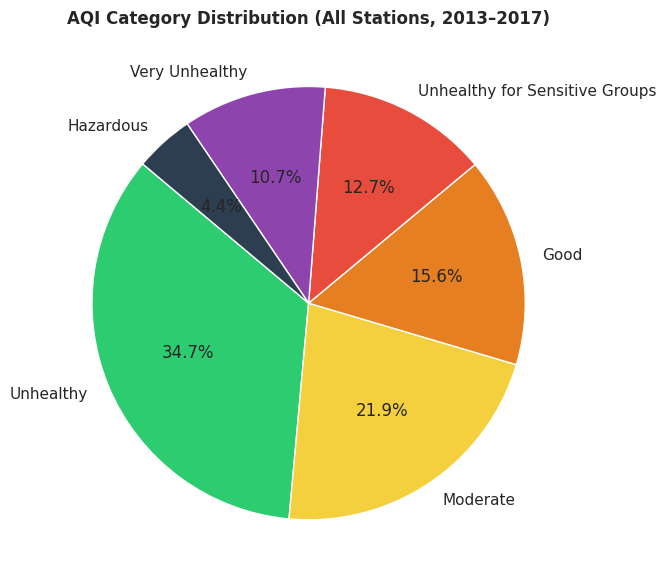

In [18]:

# UNIVARIATE — AQI CATEGORY PIE CHART ────────────────────────────
# A pie chart gives an intuitive overview of how often different health
# risk levels occur across all stations and all years.

aqi_counts = df['AQI_Category'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    aqi_counts,
    labels=aqi_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2ECC71','#F4D03F','#E67E22','#E74C3C','#8E44AD','#2C3E50']
)
ax.set_title('AQI Category Distribution (All Stations, 2013–2017)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('plot_03_aqi_pie.png', bbox_inches='tight')
plt.show()



INTERPRETATION:
A large proportion of hourly readings fall into Unhealthy or worse categories,
highlighting the severity of Beijing's air quality problem during this period.
Only a small fraction meet the 'Good' standard set by US EPA guidelines.


In [19]:
# BIVARIATE — PM2.5 vs TEMPERATURE ───────────────────────────────
# Scatter plot examines whether there is a relationship between temperature
# and PM2.5 concentration. Cold weather often traps pollutants near the
# ground (temperature inversion), so we expect higher PM2.5 in winter (low TEMP).
# Colour-coding by station allows station-level comparison simultaneously.

fig = px.scatter(
    df.sample(10000, random_state=42),   # sample for performance
    x='TEMP', y='PM2.5',
    color='station',
    opacity=0.4,
    title='PM2.5 vs Temperature by Station',
    labels={'TEMP': 'Temperature (°C)', 'PM2.5': 'PM2.5 (µg/m³)'}
)
fig.update_layout(height=450)
fig.show()



INTERPRETATION
(OVERALL RELATIONSHIP):
The scatter plot reveals a clear negative relationship between temperature
and PM2.5 concentration — as temperature decreases, PM2.5 levels tend to
increase. This pattern is consistent across all four monitoring stations
and aligns with established atmospheric science literature on pollution
behaviour in cold climates.

COLD WEATHER AND HIGH POLLUTION:
The highest PM2.5 concentrations (above 150 µg/m³) are clustered at
temperatures below 10°C, corresponding to Beijing's winter months
(December to February). During this period, two compounding factors
drive PM2.5 upward:
  1. Coal-burning heating systems emit large volumes of particulate matter.
  2. Temperature inversions — where a layer of warm air traps cold, stagnant
     air near the ground — prevent pollutants from dispersing vertically,
     causing them to accumulate close to the surface.

WARM WEATHER AND LOWER POLLUTION:
At higher temperatures (above 20°C), PM2.5 values are generally lower and
less variable. Warmer summer conditions promote greater atmospheric mixing,
increased boundary layer height, and more frequent rainfall — all of which
help to disperse and remove pollutants from the lower atmosphere.

STATION-LEVEL DIFFERENCES:
Colour-coding by station reveals that inner urban stations (Dongsi and
Tiantan) tend to show higher PM2.5 values at the same temperature compared
to outer suburban stations (Huairou and Shunyi). This difference is
particularly pronounced at low temperatures, suggesting that urban heat
sources — traffic, industry, and dense heating infrastructure — contribute
additional pollutant loading beyond the seasonal effect alone.

SPREAD AND VARIABILITY:
The scatter is wide at all temperature ranges, indicating that temperature
alone does not fully explain PM2.5 variation. Other factors such as wind
speed, rainfall, and proximity to emission sources also play a significant
role, which is confirmed by the multivariate correlation analysis presented
in Section 2.3g.

CONCLUSION:
Temperature is a meaningful predictor of PM2.5 concentration, particularly
at the seasonal level. The negative association observed here provides
justification for including TEMP as a feature in the Task 3 machine
learning model, where it is expected to contribute meaningfully to
prediction accuracy alongside other meteorological and pollutant variables.

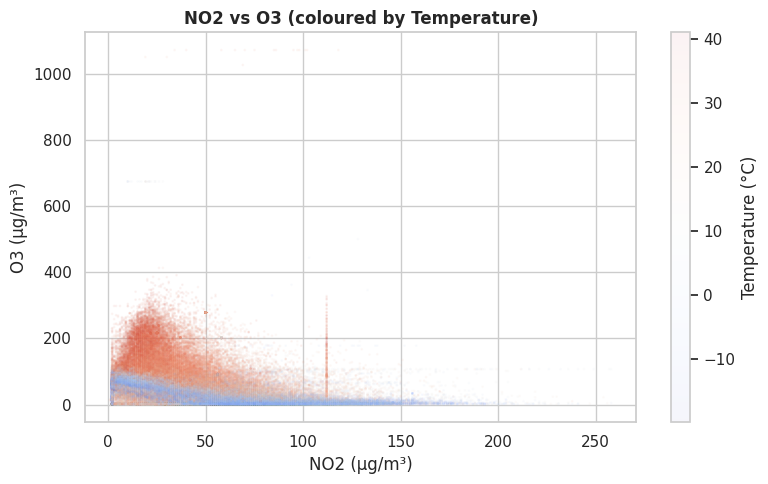

In [20]:
# BIVARIATE — NO2 vs O3 ──────────────────────────────────────────
# NO2 and O3 have a well-known inverse relationship in atmospheric chemistry:
# High NO2 (traffic/combustion) tends to deplete O3 via this reaction chain.

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df['NO2'], df['O3'],
    alpha=0.05, s=1, c=df['TEMP'], cmap='coolwarm'
)
plt.colorbar(scatter, ax=ax, label='Temperature (°C)')
ax.set_xlabel('NO2 (µg/m³)')
ax.set_ylabel('O3 (µg/m³)')
ax.set_title('NO2 vs O3 (coloured by Temperature)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_NO2_vs_O3.png', bbox_inches='tight')
plt.show()


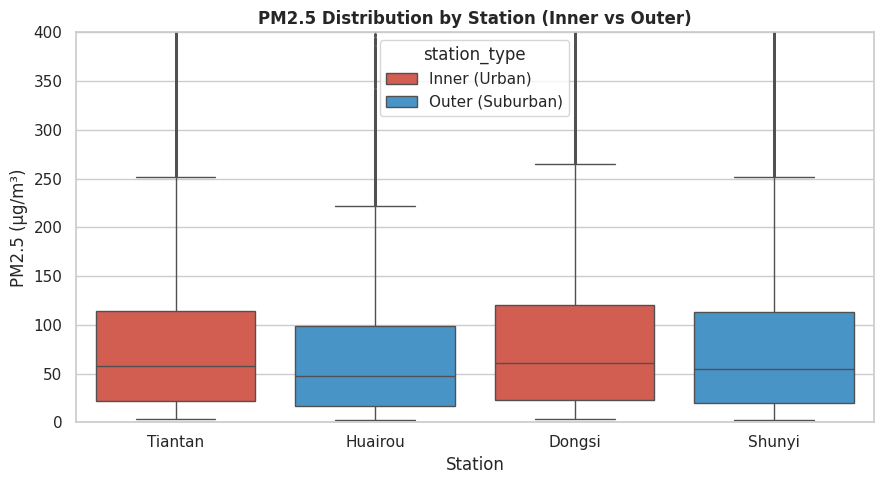

In [21]:
# BIVARIATE — PM2.5 BY STATION TYPE (BOX PLOT) ───────────────────
# A box plot compares the distribution of PM2.5 between inner (urban)
# and outer (suburban) stations. The box shows the interquartile range (IQR),
# the line inside the box is the median, and points beyond the whiskers are outliers.

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df, x='station', y='PM2.5', hue='station_type',
    palette={'Inner (Urban)': '#E74C3C', 'Outer (Suburban)': '#3498DB'},
    fliersize=1, ax=ax
)
ax.set_title('PM2.5 Distribution by Station (Inner vs Outer)', fontweight='bold')
ax.set_xlabel('Station')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_ylim(0, 400)   # cap y-axis to avoid extreme outliers compressing the box
plt.tight_layout()
plt.savefig('plot_05_pm25_by_station.png', bbox_inches='tight')
plt.show()


INTERPRETATION:
Inner (urban) stations generally show higher median PM2.5 and wider IQR
than outer (suburban) stations, confirming that urban areas experience
more severe and more variable air pollution, likely due to higher traffic
density and proximity to industrial emission sources.


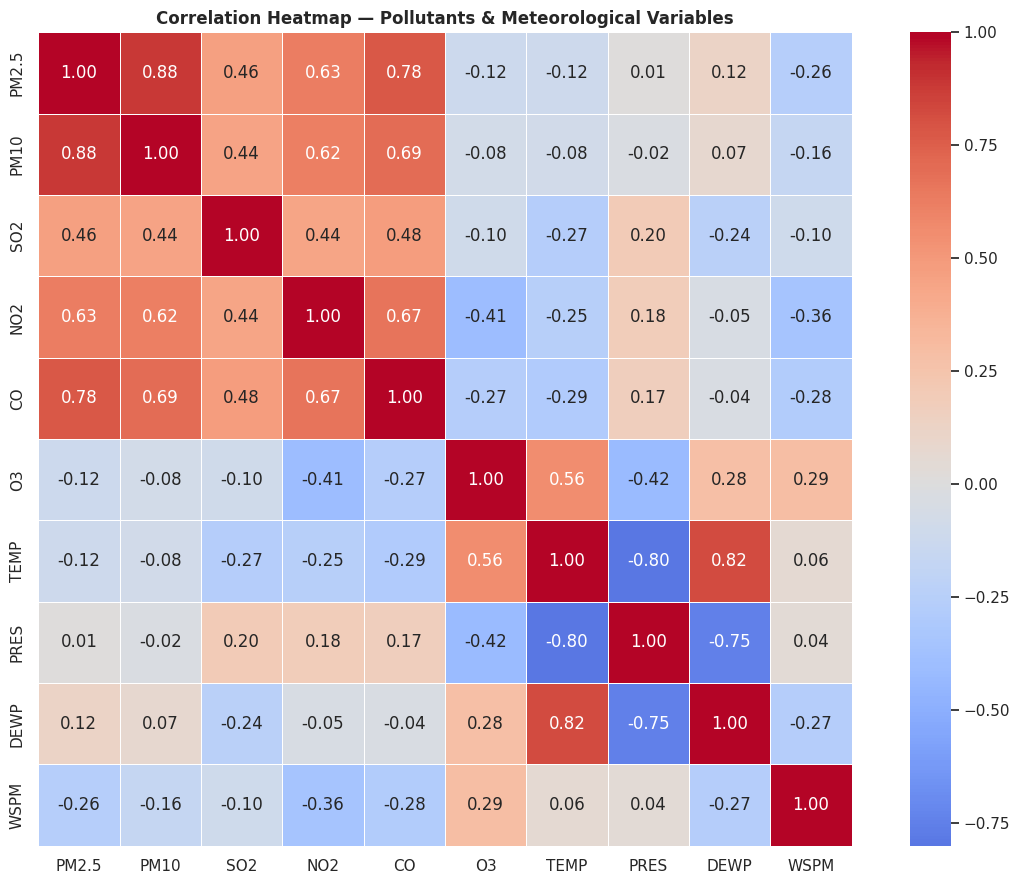

In [22]:
# MULTIVARIATE — CORRELATION HEATMAP ─────────────────────────────
# A correlation heatmap shows the pairwise Pearson correlation coefficient
# between all numeric variables. Values range from -1 (perfect negative)
# to +1 (perfect positive). Helps identify which variables are related
# and which to include as features in the machine learning model.

corr_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
             'TEMP', 'PRES', 'DEWP', 'WSPM']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True,
    ax=ax
)
ax.set_title('Correlation Heatmap — Pollutants & Meteorological Variables',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('plot_06_correlation_heatmap.png', bbox_inches='tight')
plt.show()



INTERPRETATION:
Strong positive correlations: PM2.5 & PM10, PM2.5 & CO, PM2.5 & NO2
  → These pollutants share common sources (traffic, combustion).
Strong negative correlations: O3 & NO2, O3 & CO
  → Confirms the photochemical inverse relationship.
TEMP & DEWP positively correlated → warmer air holds more moisture.
WSPM negatively correlated with most pollutants → wind disperses pollution.


In [23]:
#MULTIVARIATE — MONTHLY PM2.5 TIME SERIES ───────────────────────
# A line chart of monthly average PM2.5 reveals long-term trends and
# seasonal cycles. We group by year + month + station and compute the mean.
# Plotly makes this interactive — you can hover to see exact values
# and toggle stations on/off.

monthly_avg = (
    df.groupby(['year', 'month', 'station'])['PM2.5']
      .mean()
      .reset_index()
)
# Create a proper date column for plotting on the x-axis
monthly_avg['date'] = pd.to_datetime(
    monthly_avg[['year', 'month']].assign(day=1)
)

fig = px.line(
    monthly_avg,
    x='date', y='PM2.5', color='station',
    title='Monthly Average PM2.5 by Station (March 2013 – February 2017)',
    labels={'PM2.5': 'Avg PM2.5 (µg/m³)', 'date': 'Date', 'station': 'Station'}
)
fig.update_layout(height=450, hovermode='x unified')
fig.show()



INTERPRETATION:
All stations show clear seasonal cycles — PM2.5 peaks in winter (Dec–Feb)
and drops in summer (Jun–Aug). Urban stations consistently show higher
peaks. Huairou (outer) consistently records the lowest PM2.5 levels,
reflecting its distance from urban emission sources.


In [24]:
# ── 2.3i: MULTIVARIATE — SEASONAL PM2.5 COMPARISON ───────────────────────
# Grouped bar chart comparing average PM2.5 across all four seasons
# for each station. This clearly shows which season and which station
# experiences the worst air quality.

seasonal_avg = (
    df.groupby(['season', 'station'])['PM2.5']
      .mean()
      .reset_index()
)

fig = px.bar(
    seasonal_avg,
    x='season', y='PM2.5', color='station',
    barmode='group',
    title='Average PM2.5 by Season and Station',
    labels={'PM2.5': 'Avg PM2.5 (µg/m³)', 'season': 'Season'},
    category_orders={'season': ['Spring', 'Summer', 'Autumn', 'Winter']}
)
fig.update_layout(height=420)
fig.show()



INTERPRETATION:
Winter is consistently the worst season for PM2.5 across all stations —
driven by coal heating and atmospheric inversions that trap pollutants.
Summer shows the lowest PM2.5, likely due to increased wind, rain, and
the absence of heating emissions. The gap between inner and outer
stations is most pronounced in winter.
